In [5]:
#Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported")

Libraries imported


Dataset contains 2,075,259 minute-level measurements from Dec 2006 to Nov 2010.
file uses ; as a seprator and Date , Time for merged it into datetion.

In [6]:
#Load dataset
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',                                        # semicolon separated
    parse_dates={'datetime': ['Date', 'Time']},     # merge Date + Time
    dayfirst=True,                                  # dd/mm/yyyy format
    na_values=['?'],                                # '?' = missing
    low_memory=False
)

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

# Force numeric types
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data loaded")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(10))

Data loaded
Shape: (2075259, 7)
Date range: 2006-12-16 17:24:00 → 2010-11-26 21:02:00
Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   
2006-12-16 17:29:00                3.520                  0.522   235.02   
2006-12-16 17:30:00                3.702                  0.520   235.09   
2006-12-16 17:31:00                3.700                  0.520   235.22   
2006-12-16 

In [7]:
#Check missing values
print("Missing values BEFORE:")
print(df.isnull().sum())

# Time-based interpolation (best for continuous physical measurements)
df = df.interpolate(method='time', limit=60)
df.ffill(inplace=True)
df.bfill(inplace=True)

print("\nMissing values AFTER:", df.isnull().sum().sum())
print("Missing values handled")

Missing values BEFORE:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values AFTER: 0
Missing values handled


In [8]:
#make it from 1-minute → 1-hour
# preserves daily/weekly patterns for ML models.
df = df.resample('h').mean()

# Fix small gaps created by resampling
df.interpolate(method='time', limit=3, inplace=True)
df.dropna(inplace=True)

print("Resampled to hourly")
print(f"New shape: {df.shape}")

Resampled to hourly
New shape: (34589, 7)


* Feature Engineering

In [9]:
#Create time-based features

idx = df.index
df['hour']         = idx.hour
df['day_of_week']  = idx.dayofweek          # 0=Mon, 6=Sun
df['month']        = idx.month
df['is_weekend']   = (idx.dayofweek >= 5).astype(int)

# Cyclical encoding (hour & month are periodic)
df['hour_sin']  = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print(df.columns.tolist())

['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


In [17]:
# Lag fetures
TARGET = 'Global_active_power'

for lag in [1, 2, 3, 24, 48, 168]:        # 1h, 2h, 3h, 1d, 2d, 1 week
    df[f'{TARGET}_lag_{lag}'] = df[TARGET].shift(lag)

# Rolling statistics
for window in [6, 24, 168]:
    df[f'{TARGET}_roll_mean_{window}'] = df[TARGET].rolling(window).mean()
    df[f'{TARGET}_roll_std_{window}']  = df[TARGET].rolling(window).std()

df.dropna(inplace=True)                  

print(f"Final shape: {df.shape}")

Final shape: (34253, 27)


* Exploratory Data Analysis (EDA)

Summary Statistics:
                                     count     mean    std      min      25%  \
Global_active_power                34253.0    1.079  0.888    0.124    0.342   
Global_reactive_power              34253.0    0.123  0.067    0.000    0.078   
Voltage                            34253.0  240.833  2.992  225.834  239.197   
Global_intensity                   34253.0    4.573  3.716    0.503    1.510   
Sub_metering_1                     34253.0    1.110  3.516    0.000    0.000   
Sub_metering_2                     34253.0    1.277  4.140    0.000    0.000   
Sub_metering_3                     34253.0    6.406  7.338    0.000    0.650   
hour                               34253.0   11.501  6.922    0.000    6.000   
day_of_week                        34253.0    2.999  2.000    0.000    1.000   
month                              34253.0    6.396  3.388    1.000    3.000   
is_weekend                         34253.0    0.285  0.452    0.000    0.000   
hour_sin            

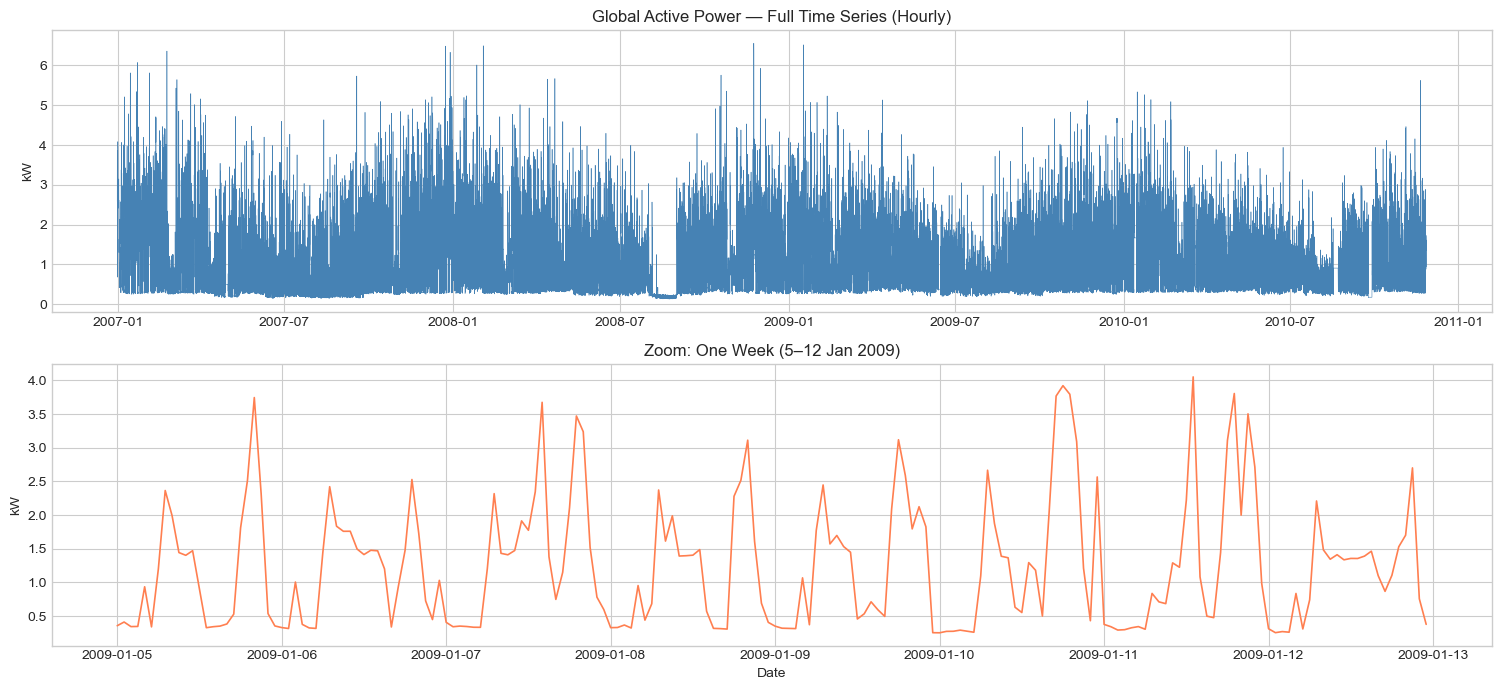

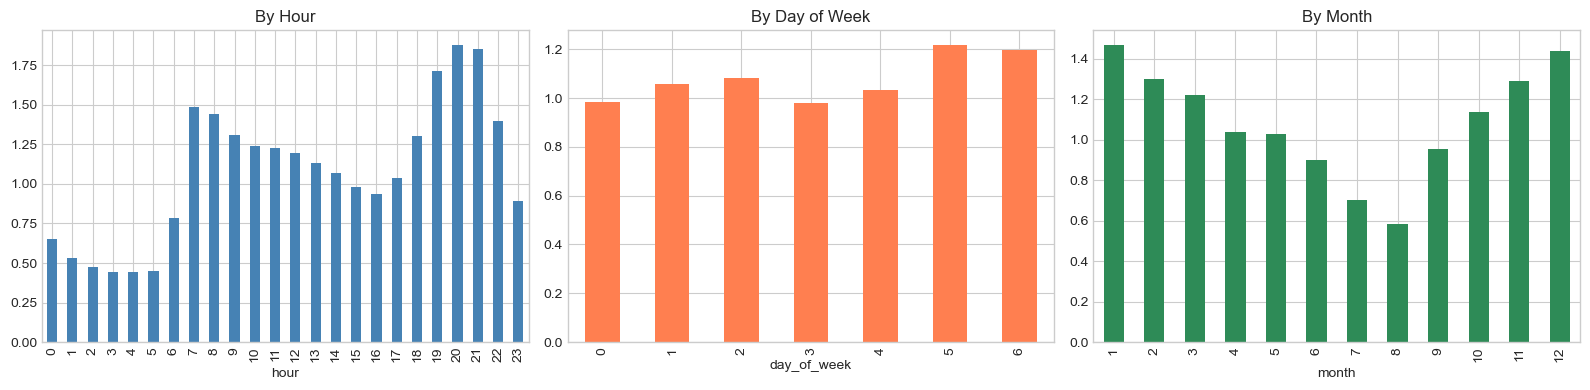

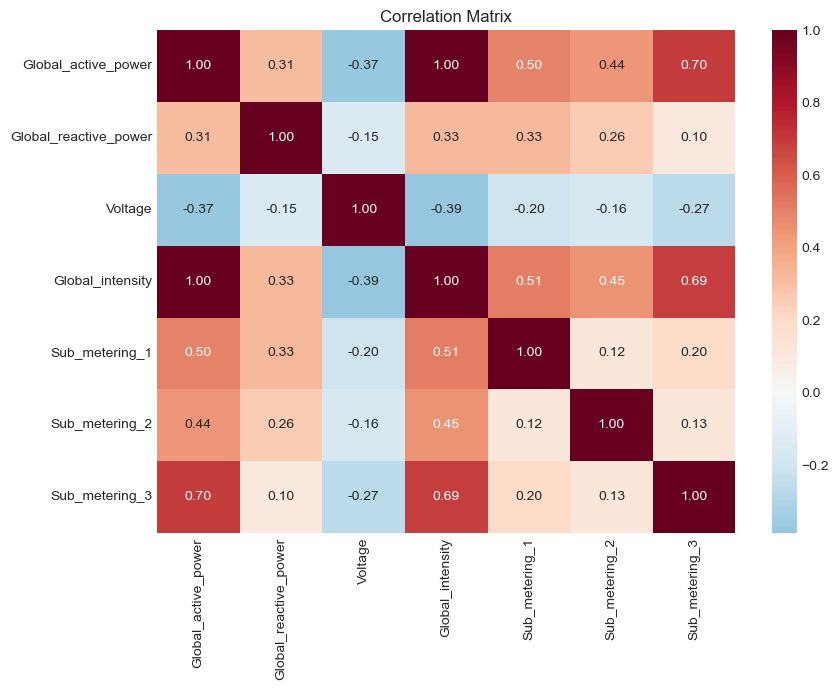

In [18]:
#EDA — summary + visualizations

#Summary statistics
print("Summary Statistics:")
print(df.describe().T.round(3))

#Time series plot (full + one week zoom)
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=False)
axes[0].plot(df.index, df[TARGET], linewidth=0.4, color='steelblue')
axes[0].set_title('Global Active Power — Full Time Series (Hourly)')
axes[0].set_ylabel('kW')

zoom = df.loc['2009-01-05':'2009-01-12']
axes[1].plot(zoom.index, zoom[TARGET], color='coral', linewidth=1.2)
axes[1].set_title('Zoom: One Week (5–12 Jan 2009)')
axes[1].set_ylabel('kW'); axes[1].set_xlabel('Date')
plt.tight_layout(); plt.show()

# Seasonality
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df.groupby('hour')[TARGET].mean().plot(ax=axes[0], kind='bar',color='steelblue', title='By Hour')
df.groupby('day_of_week')[TARGET].mean().plot(ax=axes[1], kind='bar',color='coral', title='By Day of Week')
df.groupby('month')[TARGET].mean().plot(ax=axes[2], kind='bar',color='seagreen', title='By Month')
plt.tight_layout(); plt.show()

#Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df[['Global_active_power','Global_reactive_power','Voltage',
                'Global_intensity','Sub_metering_1','Sub_metering_2',
                'Sub_metering_3']].corr(),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

* Train/Test Split 

In [19]:
#Split 80/20 

feature_cols = [c for c in df.columns
                if c != TARGET and df[c].dtype in ['float64', 'int64']]

split_idx = int(len(df) * 0.8)

X_train = df[feature_cols].iloc[:split_idx]
X_test  = df[feature_cols].iloc[split_idx:]
y_train = df[TARGET].iloc[:split_idx]
y_test  = df[TARGET].iloc[split_idx:]

# Scale (fit on train only — no data leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train):,} samples")
print(f"Test : {len(X_test):,} samples")

Train: 27,402 samples
Test : 6,851 samples


In [ ]:
#Train 3 ML models and evaluate

def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE':   mean_absolute_error(y_true, y_pred),
        'RMSE':  np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':    r2_score(y_true, y_pred),
        'y_pred': y_pred
    }

results = []

#Linear Regression — baseline
lr = LinearRegression().fit(X_train_sc, y_train)
results.append(evaluate('Linear Regression', y_test, lr.predict(X_test_sc)))

#Random Forest — nonlinear ensemble
rf = RandomForestRegressor(n_estimators=100, max_depth=15,
                            random_state=42, n_jobs=-1).fit(X_train_sc, y_train)
results.append(evaluate('Random Forest', y_test, rf.predict(X_test_sc)))

#Gradient Boosting — boosting ensemble
gb = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1,
                                max_depth=5, random_state=42).fit(X_train_sc, y_train)
results.append(evaluate('Gradient Boosting', y_test, gb.predict(X_test_sc)))

# Show results
results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='y_pred'}
                            for r in results]).set_index('Model').round(4)
print("ML models trained\n")
print(results_df)

In [14]:
#LSTM for time-series forecasting

SEQ_LEN = 24    # use past 24 hours to predict next hour

# Scale target series to [0,1]
lstm_scaler = MinMaxScaler()
series = lstm_scaler.fit_transform(df[TARGET].values.reshape(-1, 1))

# Build sequences
X_seq, y_seq = [], []
for i in range(len(series) - SEQ_LEN):
    X_seq.append(series[i:i+SEQ_LEN, 0])
    y_seq.append(series[i+SEQ_LEN, 0])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# Chronological split
s = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:s], X_seq[s:]
y_tr, y_te = y_seq[:s], y_seq[s:]
X_tr = X_tr.reshape(-1, SEQ_LEN, 1)
X_te = X_te.reshape(-1, SEQ_LEN, 1)

# Build model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Train
history = model.fit(X_tr, y_tr, epochs=20, batch_size=64,
                    validation_split=0.1, verbose=1,
                    callbacks=[EarlyStopping(monitor='val_loss',
                                             patience=5,
                                             restore_best_weights=True)])

# Predict & inverse-transform
y_pred_lstm = lstm_scaler.inverse_transform(
    model.predict(X_te).reshape(-1,1)).flatten()
y_true_lstm = lstm_scaler.inverse_transform(
    y_te.reshape(-1,1)).flatten()

results.append(evaluate('LSTM', y_true_lstm, y_pred_lstm))
print("✅ LSTM trained")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0145 - mae: 0.0906 - val_loss: 0.0108 - val_mae: 0.0766
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0102 - mae: 0.0724 - val_loss: 0.0102 - val_mae: 0.0737
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0098 - mae: 0.0700 - val_loss: 0.0095 - val_mae: 0.0709
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0094 - mae: 0.0682 - val_loss: 0.0094 - val_mae: 0.0690
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0093 - mae: 0.0673 - val_loss: 0.0093 - val_mae: 0.0685
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0091 - mae: 0.0667 - val_loss: 0.0091 - val_mae: 0.0681
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0091 - mae: 0.0665 - val_loss: 0.0091 - val_mae: 0.0677
Epoch 8/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0089 - mae: 0.0659 - val_loss: 0.0091 - val_mae: 0.0675
Epoch 9/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms

In [ ]:
#Compare all models

results_df = pd.DataFrame([{k:v for k,v in r.items() if k!='y_pred'}
                            for r in results]).set_index('Model')
results_df = results_df.sort_values('RMSE').round(4)

print("="*55)
print("FINAL MODEL COMPARISON")
print("="*55)
print(results_df)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ['MAE','RMSE','R2']):
    ax.barh(results_df.index, results_df[m], color='steelblue')
    ax.set_title(m); ax.invert_yaxis()
plt.tight_layout(); plt.show()

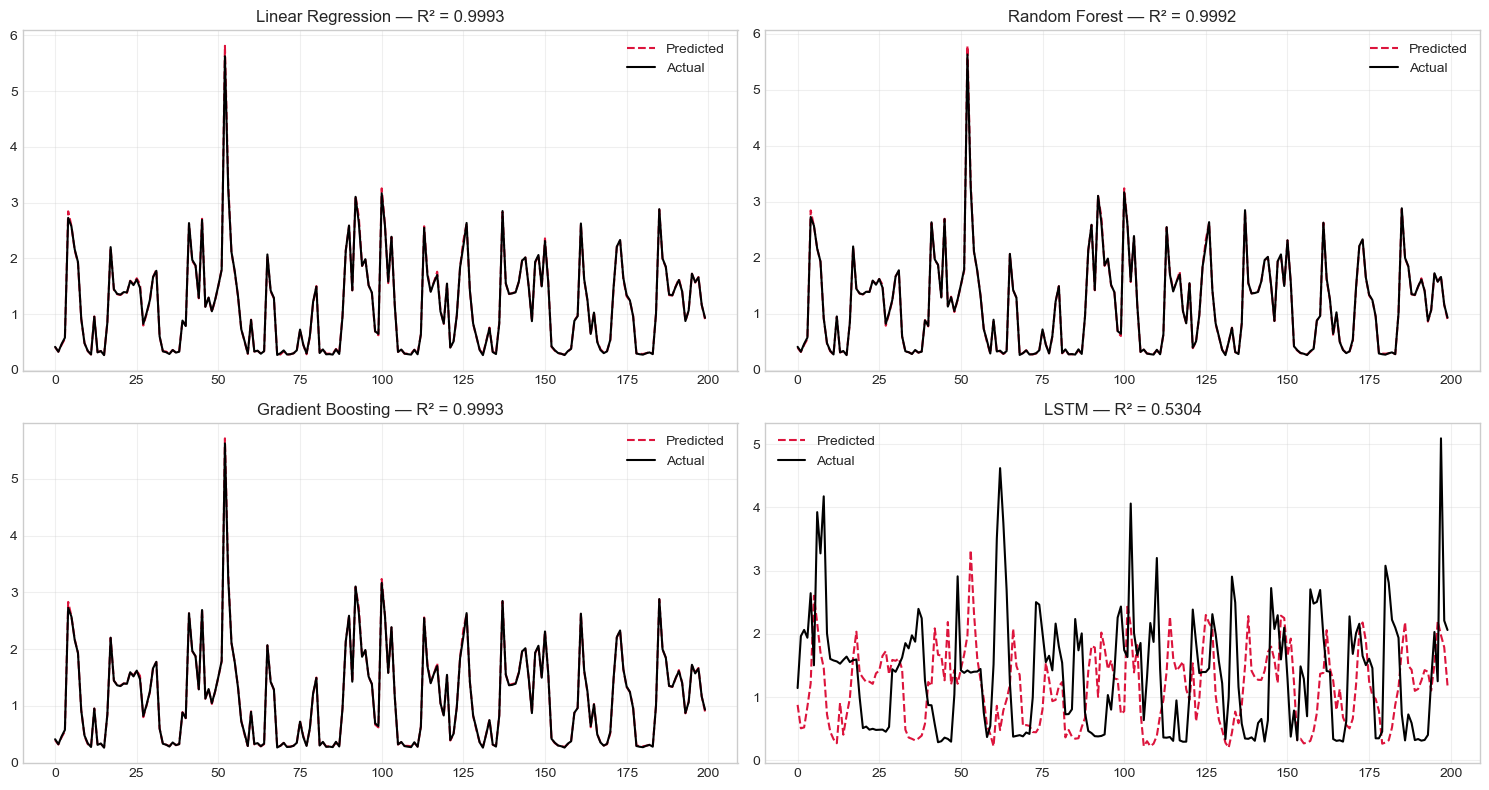

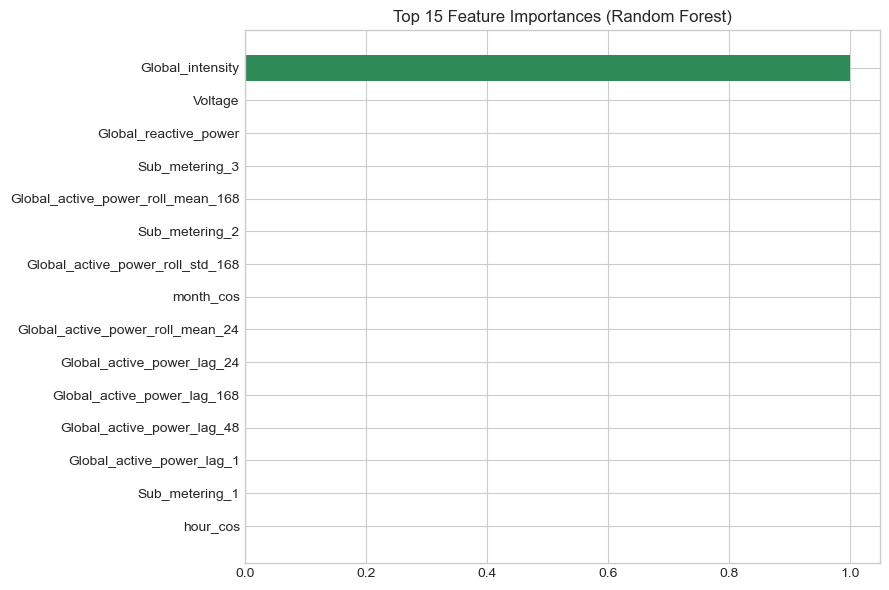

In [16]:
# STEP 12: Visualise predictions

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()
n = 200   # show last 200 test hours

for ax, name in zip(axes, ['Linear Regression', 'Random Forest',
                            'Gradient Boosting', 'LSTM']):
    r = next(r for r in results if r['Model'] == name)
    ax.plot(r['y_pred'][-n:], label='Predicted', color='crimson', linestyle='--')
    # For non-LSTM, align with y_test
    if name != 'LSTM':
        ax.plot(y_test.values[-n:], label='Actual', color='black')
    else:
        ax.plot(y_true_lstm[:n], label='Actual', color='black')
    ax.set_title(f"{name} — R² = {r['R2']:.4f}")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Feature importance (Random Forest)
fi = pd.DataFrame({'feature': feature_cols,
                    'importance': rf.feature_importances_}
                  ).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color='seagreen')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout(); plt.show()